In [1]:
import h5py
import numpy as np
import scipy.sparse as sp

f = h5py.File('../data/raw/Visium_HD_Human_Colon_Cancer_feature_slice.h5', 'r')

slice_id = list(f['feature_slices'].keys())[0]
print(slice_id)

grp = f['feature_slices'][slice_id]

data = grp['data'][:]
row = grp['row'][:]
col = grp['col'][:]

X = sp.csr_matrix((data, (row, col)))

print(X.shape)

100
(3213, 3332)


In [2]:
X = X.T  # transpose

print(X.shape)

(3332, 3213)


Get barcodes + genes

In [3]:
print(list(f['features'].keys()))

genes = f['features']['id'][:].astype(str)

print(list(f['feature_slices'].keys())[:5])

['_all_tag_keys', 'feature_type', 'genome', 'id', 'name', 'target_sets']
['100', '10000', '1001', '10014', '10016']


In [4]:
import h5py

f = h5py.File('../data/raw/Visium_HD_Human_Colon_Cancer_feature_slice.h5', 'r')

print(list(f.keys()))

['feature_slices', 'features', 'images', 'masks', 'reads', 'secondary_analysis', 'segmentations', 'umis']


In [5]:
def print_tree(name, obj):
    print(name)

f.visititems(print_tree)

feature_slices
feature_slices/100
feature_slices/100/col
feature_slices/100/data
feature_slices/100/row
feature_slices/10000
feature_slices/10000/col
feature_slices/10000/data
feature_slices/10000/row
feature_slices/1001
feature_slices/1001/col
feature_slices/1001/data
feature_slices/1001/row
feature_slices/10014
feature_slices/10014/col
feature_slices/10014/data
feature_slices/10014/row
feature_slices/10016
feature_slices/10016/col
feature_slices/10016/data
feature_slices/10016/row
feature_slices/10017
feature_slices/10017/col
feature_slices/10017/data
feature_slices/10017/row
feature_slices/10018
feature_slices/10018/col
feature_slices/10018/data
feature_slices/10018/row
feature_slices/1003
feature_slices/1003/col
feature_slices/1003/data
feature_slices/1003/row
feature_slices/10030
feature_slices/10030/col
feature_slices/10030/data
feature_slices/10030/row
feature_slices/10036
feature_slices/10036/col
feature_slices/10036/data
feature_slices/10036/row
feature_slices/1004
feature_sli

In [6]:
from anndata import AnnData

adata = AnnData(X=X)

In [7]:
genes = f['features']['id'][:].astype(str)

adata.var_names = genes[:adata.shape[1]]

In [8]:
print(adata.shape)         # (3332, 3213)
print(len(adata.var_names))  # 3213

(3332, 3213)
3213


In [9]:
import pandas as pd

df = pd.read_parquet('../data/raw/barcode_mappings.parquet')

print(df.head())
print(df.columns)
print(df.shape)

            square_002um           square_008um           square_016um  \
0  s_002um_00000_00000-1  s_008um_00000_00000-1  s_016um_00000_00000-1   
1  s_002um_00000_00001-1  s_008um_00000_00000-1  s_016um_00000_00000-1   
2  s_002um_00000_00002-1  s_008um_00000_00000-1  s_016um_00000_00000-1   
3  s_002um_00000_00003-1  s_008um_00000_00000-1  s_016um_00000_00000-1   
4  s_002um_00000_00004-1  s_008um_00000_00001-1  s_016um_00000_00000-1   

              cell_id  in_nucleus  in_cell  
0                None       False    False  
1                None       False    False  
2                None       False    False  
3  cellid_000244980-1       False     True  
4  cellid_000244980-1       False     True  
Index(['square_002um', 'square_008um', 'square_016um', 'cell_id', 'in_nucleus',
       'in_cell'],
      dtype='object')
(11222500, 6)


In [10]:
import re

def extract_xy(barcode):
    match = re.search(r"s_\d+um_(\d+)_(\d+)-\d+", barcode)
    if match:
        return int(match.group(1)), int(match.group(2))
    return None, None

In [11]:
df_8um = df["square_008um"].drop_duplicates().reset_index(drop=True)

print(len(df_8um))

702244


In [19]:
df_slice = df_8um.sample(n=adata.shape[0], random_state=42).reset_index(drop=True)

In [20]:
coords_df = df_slice.str.extract(r"s_\d+um_(\d+)_(\d+)-\d+").astype(int)

adata.obs["x"] = coords_df[0].values
adata.obs["y"] = coords_df[1].values

In [21]:
print(adata.obs.head())

     x    y  x_img      y_img
0   54  768    0.0   0.000000
1   46  729    0.0   4.642772
2  589   25    0.0   9.285544
3  348  105    0.0  13.928315
4  524  512    0.0  18.571087


(6000, 3886)


(np.float64(-0.5), np.float64(5999.5), np.float64(3885.5), np.float64(-0.5))

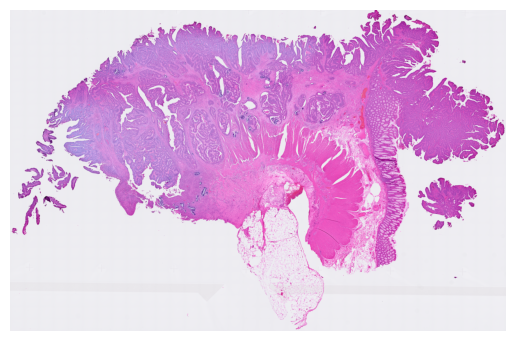

In [16]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("../data/raw/spatial/tissue_hires_image.png")

print(img.size)  # (width, height)

plt.imshow(img)
plt.axis("off")

In [22]:
xs = adata.obs["x"].values
ys = adata.obs["y"].values

xs = xs / xs.max() * img.size[0]
ys = ys / ys.max() * img.size[1]

adata.obs["x_img"] = xs
adata.obs["y_img"] = ys

(np.float64(-0.5),
 np.float64(6300.025),
 np.float64(4080.325),
 np.float64(-0.5))

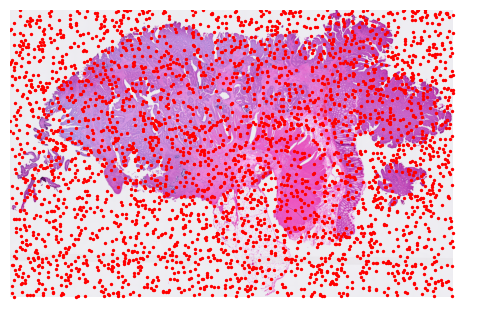

In [23]:
plt.figure(figsize=(6,6))
plt.imshow(img)

plt.scatter(
    adata.obs["x_img"],
    adata.obs["y_img"],
    s=2,
    c="red"
)

plt.axis("off")

In [24]:
import os

# create folder if not exists
os.makedirs("../data/processed", exist_ok=True)

# save
adata.write("../data/processed/adata_slice_100.h5ad")

print("Saved successfully!")

Saved successfully!
